# Generate a Synthetic Network and Measure/Plot Properties

### Setup

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from msean import load_config, save_config
from msean.generation import gen
from msean.measurements.properties import get_degree_dist, get_degree_dist_layers, get_embeddedness_dist
from msean.io.save import prepare_run_directory

Load configuration from file <b>configs/default.yaml</b> and prepare output folder inside <b>runs/</b>.

In [2]:
# Load configuration file
root = Path.cwd().parents[0] # go up from notebooks/ to project root
cfg = load_config(root / "configs" / "default.yaml")

# Create experiment folder inside runs/
paths = prepare_run_directory(cfg)
# Save config.yaml file used for experiment
save_config(cfg, paths["config"])

### Network Generation

In [3]:
G, layers = gen(cfg)

### Property Analysis

Degree distribution

In [4]:
deg_dist = get_degree_dist(G)

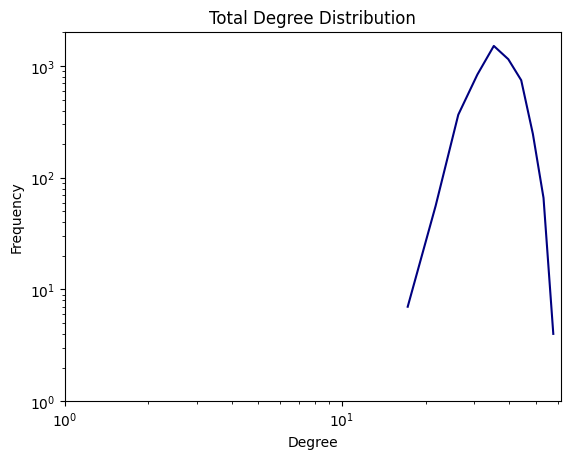

In [5]:
k = deg_dist[:, 0]     # degrees
freq = deg_dist[:, 1]  # counts

fig = plt.figure()

# Bin the degree values, weighted by their frequencies
freqs, bin_edges = np.histogram(k, weights=freq)

# Midpoints of bins
bin_mids = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Plot the frequencies against the midpoints.
plt.plot(bin_mids, freqs, color='navy')

# Specify the settings of the figure.
plt.title("Total Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
# The figure uses a log-log scale.
plt.xscale('log')
plt.yscale('log')
plt.xlim(1, plt.xlim()[1])
plt.ylim(1, plt.ylim()[1])

plt.show()

In [6]:
# Save plot under experiment folder
fig.savefig(paths["plots"] / "degree_distribution.png")

Degree distribution per layer

In [7]:
deg_dists_layers = get_degree_dist_layers(layers)

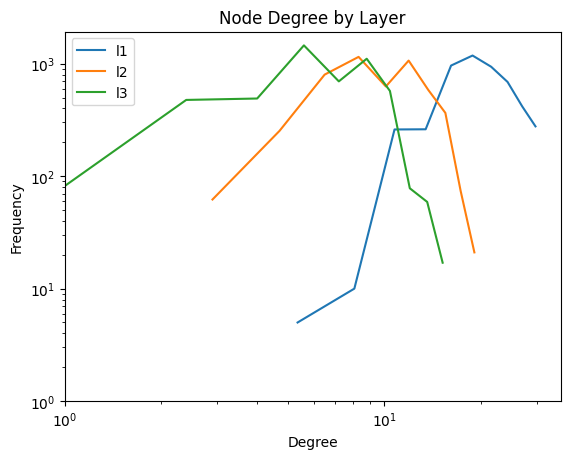

In [8]:
fig = plt.figure()

for dist, label in zip(deg_dists_layers, cfg.network.layer_labels):
    k = dist[:, 0]
    freq = dist[:, 1]

    # Bin using weights
    freqs, bin_edges = np.histogram(k, weights=freq)
    bin_mids = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.plot(bin_mids, freqs, label=label)

plt.title("Node Degree by Layer")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlim(1, plt.xlim()[1])
plt.ylim(1, plt.ylim()[1])

plt.show()
  

In [9]:
# Save plot under experiment folder
fig.savefig(paths["plots"] / "degree_distribution_layers.png")

Embededness

In [10]:
embed_dist = get_embeddedness_dist(G)

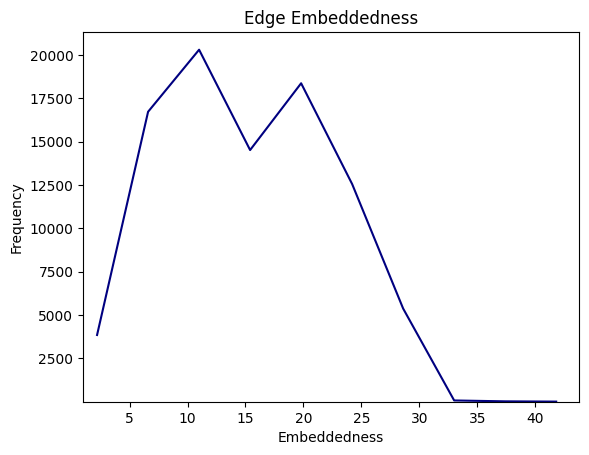

In [11]:
fig = plt.figure()

k = embed_dist[:, 0]
freq = embed_dist[:, 1]

# Bin using weights
freqs, bin_edges = np.histogram(k, weights=freq)
bin_mids = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.plot(bin_mids, freqs, color='navy')

plt.title("Edge Embeddedness")
plt.xlabel("Embeddedness")
plt.ylabel("Frequency")
plt.xlim(1, plt.xlim()[1])
plt.ylim(1, plt.ylim()[1])

plt.show()

In [12]:
# Save plot under experiment folder
fig.savefig(paths["plots"] / "embeddedness.png")